In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", palette='muted')
df = sns.load_dataset('titanic').dropna(subset=['age', 'embarked'])
df['age_group'] = pd.cut(
    df['age'],
    bins = [0,12, 18, 35, 60, 120],
    labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)
print('Dataset shape: ', df.shape)

Dataset shape:  (712, 16)


In [3]:
df['age_group'].head()

,age_group
0,Teen
1,Teen
2,Teen
3,Teen
4,Teen


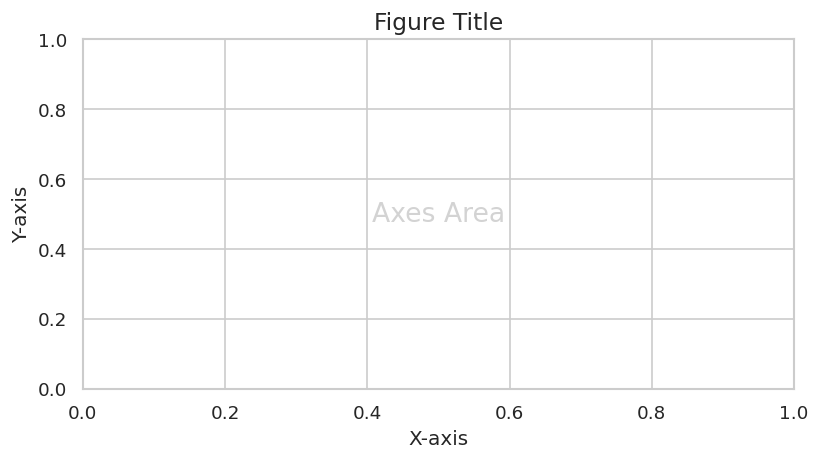

In [11]:
from matplotlib.transforms import Transform
fig, ax = plt.subplots(figsize=(7,4))

ax.set_title('Figure Title', fontsize = 14)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.text(0.5, 0.5, 'Axes Area', transform=ax.transAxes, ha='center', va='center', fontsize = 16, color='lightgray')
plt.tight_layout()
plt.show()

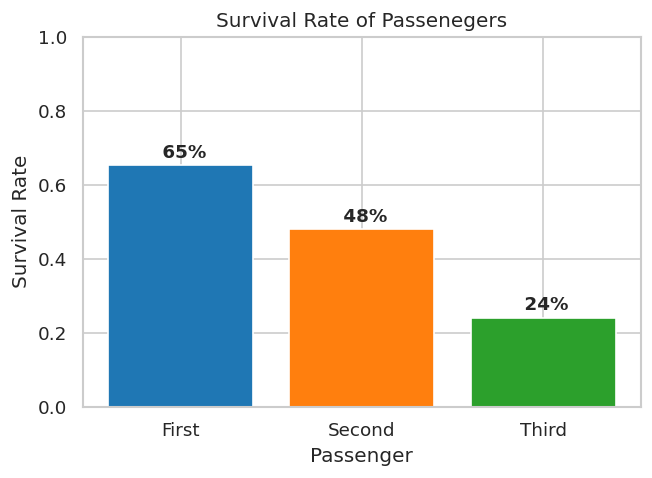

In [49]:
# Bar Chart

survival_by_class = df.groupby('pclass')['survived'].mean().reset_index()
survival_by_class.columns = ['Class', 'Survival Rate']
survival_by_class['Class'] = survival_by_class['Class'].map(({1: 'First', 2: 'Second', 3: 'Third'}))

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(survival_by_class['Class'], survival_by_class['Survival Rate'], color = ['tab:blue', 'tab:orange', 'tab:green' ])
for bar, val in zip(bars, survival_by_class['Survival Rate']):
  ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 0.01, f"{val: .0%}", ha='center', va='bottom', fontsize = 11, fontweight = 'bold')
ax.set_title('Survival Rate of Passenegers')
ax.set_xlabel('Passenger')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0,1 )
plt.show()

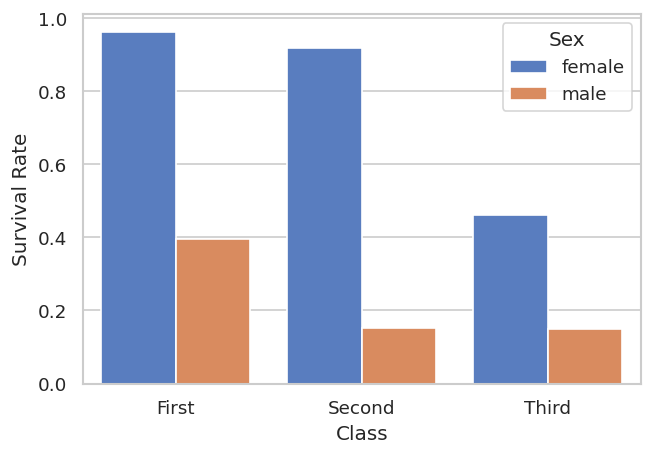

In [47]:
# Create a grouped bar chart showing survival rate by both class and sex

# Hint: Use sns.barplot with x = 'pclass', hue="sex", y='survived


survival_by_class_sex = df.groupby(['pclass', 'sex']).agg({
    'survived' : 'mean'}).reset_index()
survival_by_class_sex.columns = ['Class', 'Sex','Survival Rate']
survival_by_class_sex['Class'] = survival_by_class_sex['Class'].map(({1: 'First', 2: 'Second', 3: 'Third'}))

fig, ax = plt.subplots(figsize=(6,4))
bars = sns.barplot(data= survival_by_class_sex, x = 'Class', y = 'Survival Rate', hue = 'Sex')
plt.show()

/tmp/ipykernel_8602/2270685428.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Class')


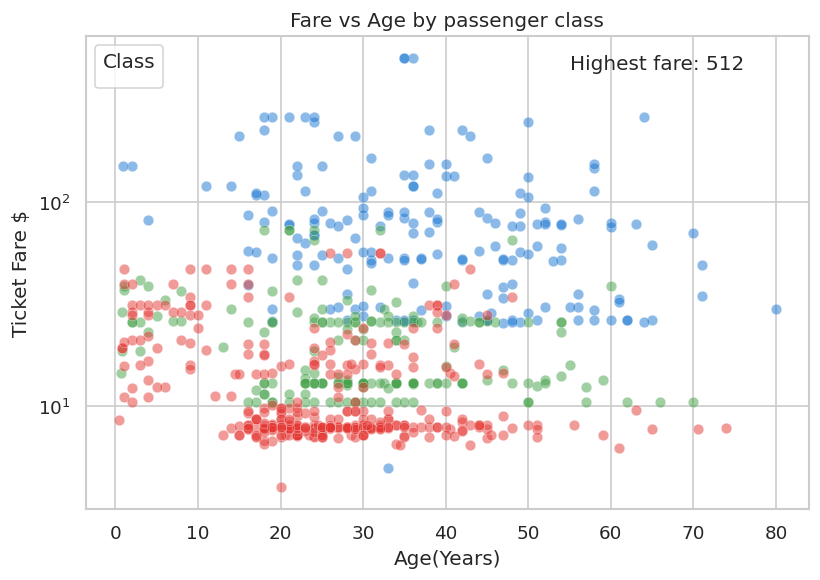

In [61]:
# Scatter Plot

fig, ax = plt.subplots( figsize = (7, 5))
colors = {1: '#1976D2', 2: '#43A047', 3: '#E53935'}
labels = {1:'1st class', 2: '2nd class', 3: '3rd class'}

for cls in [1, 2, 3]:
   subset = df[df['pclass'] == cls]
   ax.scatter(subset['age'], subset['fare'],
              c = colors[cls],
              alpha = 0.5,
              s = 40,
              edgecolors = 'white',
              linewidth=0.3
              )
ax.set_title('Fare vs Age by passenger class')
ax.set_xlabel('Age(Years)')
ax.set_ylabel('Ticket Fare $')
ax.legend(title='Class')
ax.set_yscale('log')

#Annotate an outliner
max_fare_idx = df['fare'].idxmax()
ax.annotate(
    f"Highest fare: {df.loc[max_fare_idx, 'fare']:.0f}",
    xy=(df.loc[max_fare_idx, 'age'],
        df.loc[max_fare_idx, 'fare']),
    xytext=(55, 450)
)
plt.tight_layout()
plt.show()

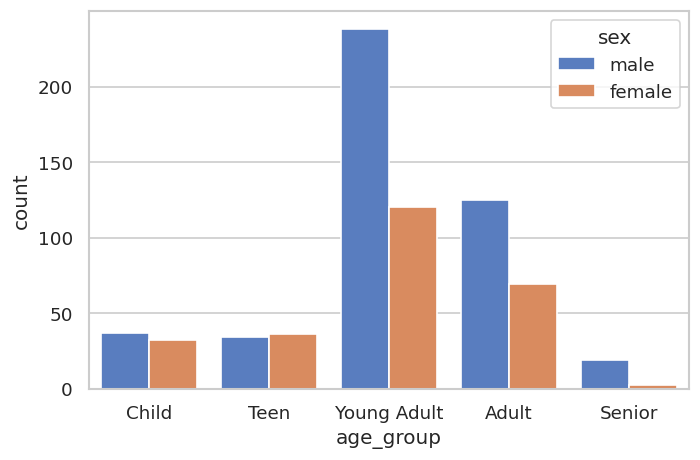

In [53]:
# Add a fifth panel -- a seaborn-countplot showing the number of passengers by age_group, colured by sex, save the full 5 panel figure
fig, ax = plt.subplots(figsize =(6, 4))
sns.countplot(
    x = 'age_group',
    hue = 'sex',
    data = df
    # ax = ax[4]
)

# ax[4].set_title('Passengers by Age Group and Sex')
plt.tight_layout()
plt.savefig('five_panel_figure.png')
plt.show()